# Dating Apps


# Introduction
In recent years, there has been a massive rise in the usage of dating apps to find love. Many of these apps use sophisticated data science techniques to recommend possible matches to users and to optimize the user experience. These apps give us access to a wealth of information that we’ve never had before about how different people experience romance.

For this project we will be looking a dataset of an app called OKCupid. This App focuses on using multiple choice and short answers to match users.
We will be formulating questions and implementing machine learning techniques to answer those questions, so let's get started

# Exploratory Data Analysis
First, let's load an inspect the data. This will help us to understand what we are working with and check if we need to clean the data

In [224]:
import pandas as pd

In [225]:
profiles = pd.read_csv("profiles.csv")
profiles.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [226]:
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

We can see that the text has html entities and tags so in order to create a model we have to get rid of the noise the text can have

In [227]:
import html 
import re

In [228]:
text_columns = [column for column in profiles.columns if profiles[column].dtype == "object"] # Get all columns that has text to clean them
profiles[text_columns] = profiles[text_columns].fillna("") # Replace NaN with empty string to avoid errors
def clean_text(text):
    text = html.unescape(text) # Remove html entities like &amp;
    text = html.unescape(text)  # In case there is a second entity inside another one
    text = re.sub(r"<.*?>", " ", text) # Removes html tags
    text = re.sub(r"[\x00-\x1F\x7F]", "", text) # Removes control chars
    text = re.sub(r"\s+", " ", text).strip() # Normalize spaces
    return text

In [229]:
for column in text_columns:
    profiles[column] = profiles[column].map(clean_text)
profiles[text_columns].head()

,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,a little extra,strictly anything,socially,never,working on college/university,about me: i would love to think that i was som...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",...,"south san francisco, california","doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,,i am die hard christopher moore fan. i don't r...,...,"oakland, california","doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,thin,anything,socially,,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,...,"san francisco, california",,straight,has cats,,m,pisces but it doesn’t matter,no,"english, french, c++",available
3,thin,vegetarian,socially,,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",...,"berkeley, california",doesn’t want kids,straight,likes cats,,m,pisces,no,"english, german (poorly)",single
4,athletic,,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",...,"san francisco, california",,straight,likes dogs and likes cats,,m,aquarius,no,english,single


Now that we have text that is clean and ready for a model we can reduce dimensionality by combining all the essay columns into a single series and removing the extra essay columns

In [230]:
essay_columns = [f"essay{i}" for i in range(10)] # List of essay names to match the columns
profiles["essay"] = profiles[essay_columns].agg(". ".join, axis=1) # Combining the text of different essay columns into a single one 
profiles = profiles.drop(columns=essay_columns) # Remove unnecessary columns
profiles.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,...,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status,essay
0,22,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,...,"doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single,about me: i would love to think that i was som...
1,35,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,...,"doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single,i am a chef: this is what that means. 1. i am ...
2,38,thin,anything,socially,,graduated from masters program,,68.0,-1,,...,,straight,has cats,,m,pisces but it doesn’t matter,no,"english, french, c++",available,"i'm not ashamed of much, but writing public te..."
3,23,thin,vegetarian,socially,,working on college/university,white,71.0,20000,student,...,doesn’t want kids,straight,likes cats,,m,pisces,no,"english, german (poorly)",single,i work in a library and go to school. . .. rea...
4,29,athletic,,socially,never,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,...,,straight,likes dogs and likes cats,,m,aquarius,no,english,single,hey how's it going? currently vague on the pro...


Now that all the text has been cleaned, we can keep going and check for missing values within the dataset. The first thing we can do is to use info() in order to get how many missing values there are.

Right now only height has missing values represented as a missing value, we need to remember that we replaced missing values of text with "" so it doesnt appear as a missing value with info() so we need to convert any empty string into a missing value and then see how we are going to handle them.

In [231]:
import numpy as np

In [232]:
text_columns = [column for column in profiles.columns if profiles[column].dtype == "object"] # Previously text_columns had essay0, essay1 ... essay9 we replaced them so we need 
                                                                                            # to get text columns again
profiles[text_columns] = profiles[text_columns].replace("", np.nan)

Now we have a lot o missing data but that doesn't mean we can't interpretate those values. Let's take a look at diet column 

In [233]:
profiles["diet"].value_counts()

diet
mostly anything        16585
anything                6183
strictly anything       5113
mostly vegetarian       3444
mostly other            1007
strictly vegetarian      875
vegetarian               667
strictly other           452
mostly vegan             338
other                    331
strictly vegan           228
vegan                    136
mostly kosher             86
mostly halal              48
strictly halal            18
strictly kosher           18
halal                     11
kosher                    11
Name: count, dtype: int64

Diet is based on the type of restrictions someone has on their nutrition, in dating apps it is common that diet answer is an optional type of answer so if someone doesn't have a diet they may choose not to answer and it would lead to a missing value. For this scenario we will treat missing values in diet as not having a diet or "anything".

In [234]:
profiles["diet"] = profiles["diet"].replace(np.nan, "anything")

In [235]:
missing_diet = profiles["diet"].isna()
missing_diet.value_counts()

diet
False    59946
Name: count, dtype: int64

There are no missing values represented in diet column, but we have a high cardinality feature, this means there are many differente answers for a categorical feature and it will add noise into the model and be harder to One hot encode it. The answers can be grouped to reduce this dimensionality, many answers are similar and we are intrested in if someone has a restrictyion on their diet, values such as "strictly anything", "anything", "mostly anything" can be represented as "anything" and values like "strictly vegan", "vegan", "mostly vegan" can be represented as vegan. By grouping similar values we don't lose information and get rid of unnecessary noise

In [236]:
profiles["diet"] = profiles["diet"].str.lower() # Normalize text 

In [237]:
def group_diet(diet):
    if "anything" in diet:
        return "anything"
    if "other" in diet:
        return "other"
    if "vegetarian" in diet:
        return "vegetarian"
    if "vegan" in diet:
        return "vegan"
    if "halal" in diet:
        return "halal"
    if "kosher" in diet:
        return "kosher"
    

In [238]:
profiles["diet"] = profiles["diet"].map(group_diet)
profiles["diet"].unique()

array(['anything', 'other', 'vegetarian', 'vegan', 'halal', 'kosher'],
      dtype=object)

In [239]:
profiles["diet"].nunique()

6

Diet now only has 6 unique values so the model will have less noise and make better predictions, plus it is easier to visualize 

In [240]:
import matplotlib.pyplot as plt

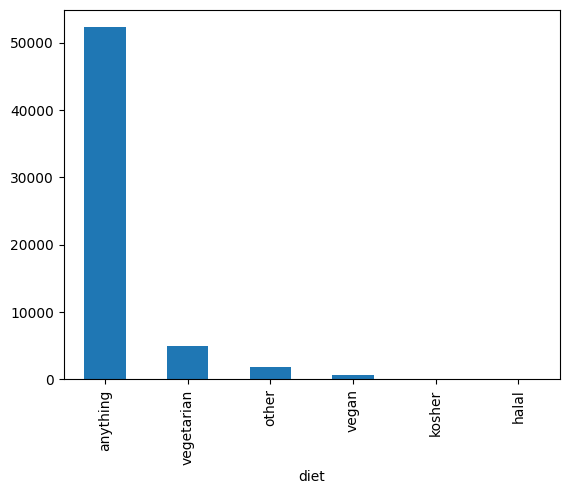

In [241]:
profiles["diet"].value_counts().plot(kind="bar")
plt.show()
plt.close()

Kosher and halal have much less impact rather than the other variables, let's see their percentages

In [242]:
profiles["diet"].value_counts(normalize=True)

diet
anything      0.872052
vegetarian    0.083175
other         0.029860
vegan         0.011711
kosher        0.001918
halal         0.001284
Name: proportion, dtype: float64

We can group this variables into "other" because it represents less than 1%

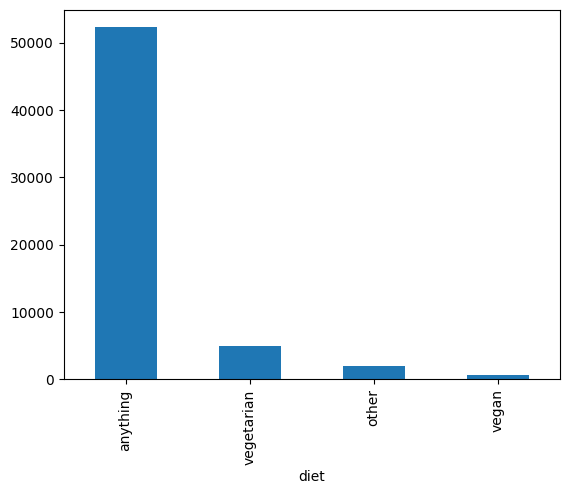

In [243]:
profiles["diet"] = profiles["diet"].apply(lambda x: "other" if "halal" in x or "kosher" in x else x)
profiles["diet"].value_counts().plot(kind="bar")
plt.show()
plt.close()

We can follow the same procedure to replace missing data with useful information or removing a row or even the entire column. Let's clean our missing data 

In [244]:
# Body type column 
profiles["body_type"].nunique()

12

In [245]:
profiles["body_type"].unique()

array(['a little extra', 'average', 'thin', 'athletic', 'fit', nan,
       'skinny', 'curvy', 'full figured', 'jacked', 'rather not say',
       'used up', 'overweight'], dtype=object)

Some values in body type are similar so we can group them into the same category which will represent the same thing

In [246]:
def group_body_type(btype):
    match btype:
        case "a little extra":
            return "curvy"
        case "average":
            return "fit"
        case "thin":
            return "skinny"
        case "":
            return "unknown"
        case "full figured":
            return "curvy"
        case "jacked":
            return "athletic"
        case "rather not say":
            return "unknown"
        case "used up":
            return "unknown"
        case _:
            return btype

In [247]:
types = profiles["body_type"].replace(np.nan, "")
types = types.map(group_body_type)
types.value_counts()

body_type
fit           27363
athletic      12240
curvy          7562
skinny         6488
unknown        5849
overweight      444
Name: count, dtype: int64

In [248]:
profiles["body_type"] = types
profiles["body_type"].unique()

array(['curvy', 'fit', 'skinny', 'athletic', 'unknown', 'overweight'],
      dtype=object)

In [249]:
import seaborn as sns 

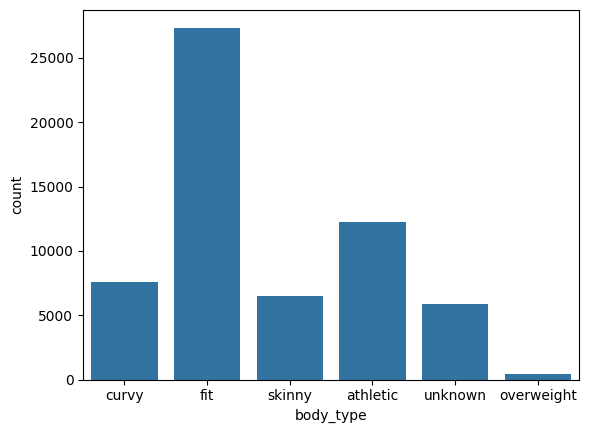

In [250]:
sns.countplot(data=profiles, x="body_type")
plt.show()
plt.close()

In [251]:
profiles["drinks"].unique()

array(['socially', 'often', 'not at all', 'rarely', nan, 'very often',
       'desperately'], dtype=object)

For the purpose of this analysis we are only interested if they drink or they don't which can be interpreted as a binary feature. If the person drinks or is quite often that happens we are going to considerate as a yes or a 1, in case they don't or they do it rarely it will be considered as a no or a 0.

In [252]:
feature_yes = ["socially", "often", "very often", "desperately"]
feature_no = ["not at all", "rarely", np.nan]
def feature_to_binary(feature):
    if feature in feature_no:
        return 0
    if feature in feature_yes:
        return 1

In [253]:
drinks = profiles["drinks"].map(feature_to_binary)
drinks.unique()

array([1, 0])

In [254]:
profiles["drinks"].unique()

array(['socially', 'often', 'not at all', 'rarely', nan, 'very often',
       'desperately'], dtype=object)

In [255]:
profiles["drinks"] = drinks

As we diid with the drinks feature we are going to do the same for drugs 

In [256]:
feature_no.append("never")
feature_yes.append("sometimes")
feature_yes.append("often")

In [257]:
drugs = profiles["drugs"].map(feature_to_binary)
drugs.unique()

array([0, 1])

In [258]:
drugs.value_counts(dropna=False)

drugs
0    51804
1     8142
Name: count, dtype: int64

In [259]:
profiles["drugs"].value_counts(dropna=False)

drugs
never        37724
NaN          14080
sometimes     7732
often          410
Name: count, dtype: int64

In [260]:
profiles["drugs"] = drugs

In [261]:
profiles["education"].unique()

array(['working on college/university', 'working on space camp',
       'graduated from masters program',
       'graduated from college/university', 'working on two-year college',
       nan, 'graduated from high school', 'working on masters program',
       'graduated from space camp', 'college/university',
       'dropped out of space camp', 'graduated from ph.d program',
       'graduated from law school', 'working on ph.d program',
       'two-year college', 'graduated from two-year college',
       'working on med school', 'dropped out of college/university',
       'space camp', 'graduated from med school',
       'dropped out of high school', 'working on high school',
       'masters program', 'dropped out of ph.d program',
       'dropped out of two-year college', 'dropped out of med school',
       'high school', 'working on law school', 'law school',
       'dropped out of masters program', 'ph.d program',
       'dropped out of law school', 'med school'], dtype=object)

By taking a look at education and ethnicity we have to reduce the number of possible answers and we are going to be using only basic classification such as high school, some college, bachelor ands postgarduate for education and a general distribution of ethnicity 

In [262]:
def group_education(text):
    if pd.isna(text):
        return "unknown"
    text = text.lower()
    if re.search(r"ph\.?d|masters", text):
        if re.search(r"dropped", text):
            return "bachelor"
        return "postgraduate"
    if re.search(r"college|law school|med school", text):
        if re.search(r"graduated", text):
            return "bachelor"
        if re.search(r"dropped", text): 
            return "high_school"
        return "some_college"
    if re.search(r"high school", text):
        if re.search(r"dropped", text):
            return "basic"
        return "high_school"
    return "unknown"

In [263]:
education = profiles["education"].map(group_education)
education.value_counts(dropna=False)

education
bachelor        27325
postgraduate    13061
some_college     8320
unknown          8311
high_school      2827
basic             102
Name: count, dtype: int64

In [264]:
profiles["education"] = education

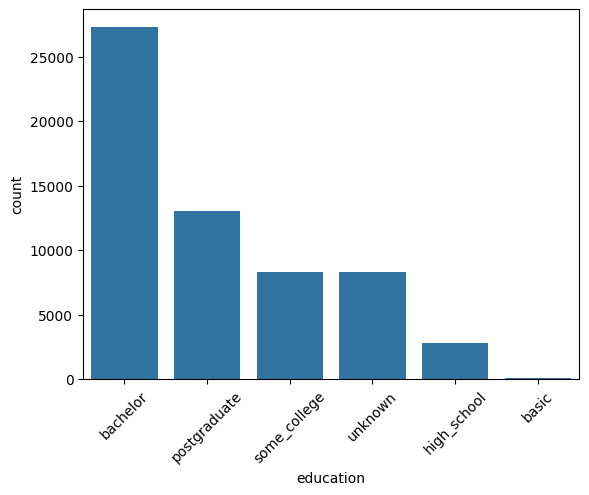

In [265]:
sns.countplot(data=profiles, x="education", order=profiles["education"].value_counts().index)
plt.xticks(rotation=45)
plt.show()
plt.close()

In [266]:
profiles["ethnicity"].unique()

array(['asian, white', 'white', nan, 'asian, black, other',
       'white, other', 'hispanic / latin, white', 'hispanic / latin',
       'pacific islander, white', 'asian', 'black, white',
       'pacific islander', 'asian, native american',
       'asian, pacific islander', 'black, native american, white',
       'middle eastern, other', 'native american, white', 'indian',
       'black', 'black, native american, hispanic / latin, other',
       'black, native american, hispanic / latin',
       'asian, black, pacific islander',
       'asian, middle eastern, black, native american, indian, pacific islander, hispanic / latin, white, other',
       'other', 'hispanic / latin, other', 'asian, black',
       'middle eastern, white', 'native american, white, other',
       'black, native american', 'black, white, other',
       'hispanic / latin, white, other', 'middle eastern', 'black, other',
       'native american, hispanic / latin, white', 'black, indian',
       'indian, white, othe

In [267]:
def group_ethnicity(text):
    if pd.isna(text):
        return "other"
    text = text.lower()
    if re.search(r",|/", text): 
        return "mixed"
    if re.search(r"asian", text):
        return "asian"
    if re.search(r"white", text):
        return "white"
    if re.search(r"black", text):
        return "black"
    if re.search(r"hispanic", text):
        return "hispanic"
    return "other"

In [268]:
ethnicity = profiles["ethnicity"].map(group_ethnicity)
ethnicity.value_counts(dropna=False, normalize=True)

ethnicity
white    0.547676
mixed    0.161512
other    0.154989
asian    0.102325
black    0.033497
Name: proportion, dtype: float64

In [269]:
profiles["ethnicity"] = ethnicity

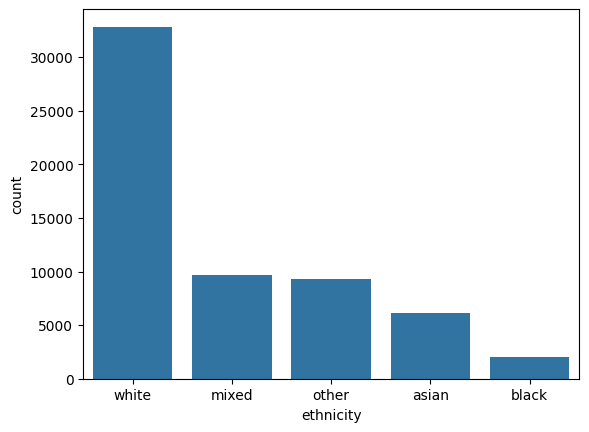

In [270]:
sns.countplot(data=profiles, x="ethnicity", order=profiles["ethnicity"].value_counts().index)
plt.show()
plt.close()

There are 3 elements that are missing from height which we can fill by placing the mean or median of the height feture, that would depend on the distribution of the values. We can create a boxplot to see just that and if it has outliers that can affect the mean 

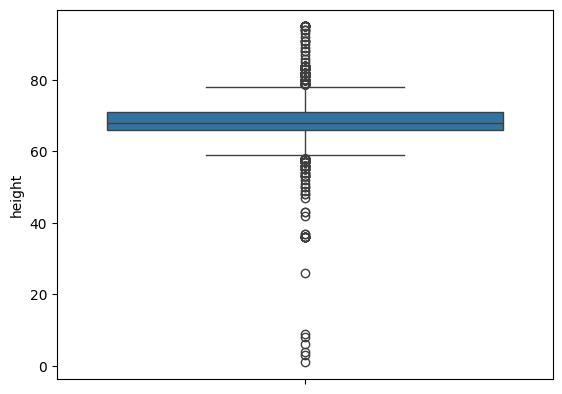

In [271]:
sns.boxplot(data=profiles, y="height", showfliers=True)
plt.show()
plt.close()

As we can see, there are a lot of outliers in this dataset, which can be derived from the ethnicity, age and other factors in general. Based on the boxplot we can determine that is safer to use the median rather than the mean in this scenario 


In [272]:
profiles["height"] = profiles["height"].fillna(profiles["height"].median())

In [276]:
profiles["job"].unique()

array(['transportation', 'hospitality / travel', nan, 'student',
       'artistic / musical / writer', 'computer / hardware / software',
       'banking / financial / real estate', 'entertainment / media',
       'sales / marketing / biz dev', 'other', 'medicine / health',
       'science / tech / engineering', 'executive / management',
       'education / academia', 'clerical / administrative',
       'construction / craftsmanship', 'rather not say',
       'political / government', 'law / legal services', 'unemployed',
       'military', 'retired'], dtype=object)

Type of jobs can be aggregated into specific classifications that we can identify using regex and the ones that doesnt havce an answer will be considered as if they are unemployed

In [277]:
def group_job(text):
    if pd.isna(text):
        return "unemployed"
    text = text.lower()
    if re.search(r"transportation", text):
        return "transportation"
    if re.search(r"travel", text):
        return "travel"
    if re.search(r"student", text): 
        return "student"
    if re.search(r"artistic|entertainment", text):
        return "entertainment"
    if re.search(r"computer|science", text):
        return "science / tech"
    if re.search(r"banking|sales", text):
        return "finance"
    if re.search(r"medicine", text):
        return "health"
    if re.search(r"executive|administrative", text):
        return "administrative"
    if re.search(r"construction", text):
        return "construction"
    if re.search(r"political|law", text):
        return "political"
    if re.search(r"rather|other", text):
        return "other"
    if re.search(r"military", text):
        return "military"
    return "unemployed"

In [278]:
job = profiles["job"].map(group_job)
job.unique()

array(['transportation', 'travel', 'unemployed', 'student',
       'entertainment', 'science / tech', 'finance', 'other', 'health',
       'administrative', 'construction', 'political', 'military'],
      dtype=object)

In [279]:
profiles["job"] = job

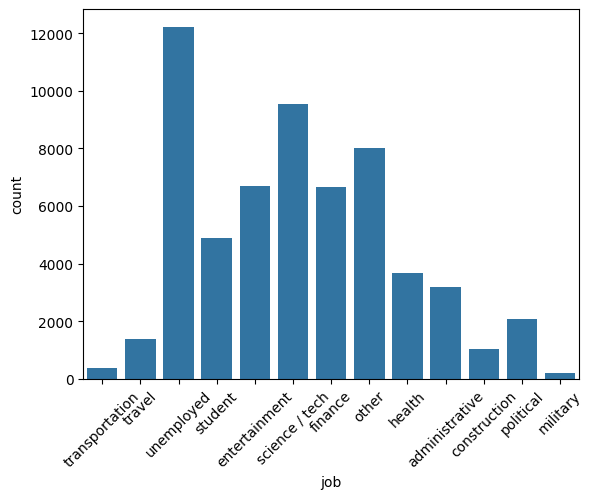

In [297]:
sns.countplot(data=profiles, x="job")
plt.xticks(rotation=45)
plt.show()
plt.close()

In [282]:
profiles["offspring"].unique()

array(['doesn’t have kids, but might want them', nan, 'doesn’t want kids',
       'doesn’t have kids, but wants them', 'doesn’t have kids',
       'wants kids', 'has a kid', 'has kids',
       'doesn’t have kids, and doesn’t want any',
       'has kids, but doesn’t want more',
       'has a kid, but doesn’t want more', 'has a kid, and wants more',
       'has kids, and might want more', 'might want kids',
       'has a kid, and might want more', 'has kids, and wants more'],
      dtype=object)

For the purpose of this analysis offspring will be used only for having or not having any kids 

In [293]:
def has_kids(text):
    if pd.isna(text):
        return 0
    text = text.lower()
    if re.search(r"has.*kids?", text):
        return 1
    return 0

In [294]:
kids = profiles["offspring"].map(has_kids)
kids.unique()

array([0, 1])

In [295]:
profiles["offspring"] = kids
profiles["offspring"].value_counts()

offspring
0    55027
1     4919
Name: count, dtype: int64

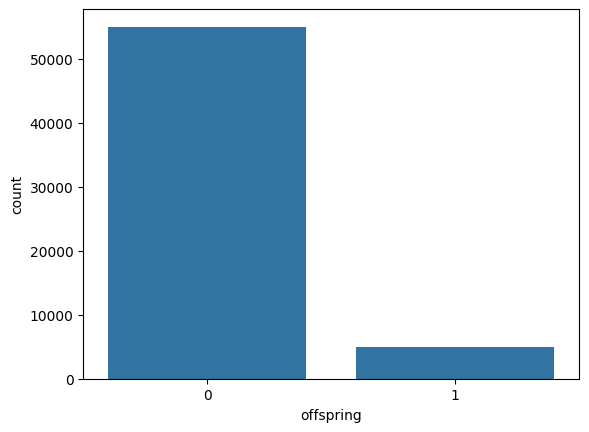

In [298]:
sns.countplot(data=profiles, x="offspring")
plt.show()
plt.close()

There is a clear difference between the ones that have kids and the ones who doesn't, which makes sense since is a dating app

In [301]:
profiles["pets"].unique()

array(['likes dogs and likes cats', 'has cats', 'likes cats', nan,
       'has dogs and likes cats', 'likes dogs and has cats',
       'likes dogs and dislikes cats', 'has dogs',
       'has dogs and dislikes cats', 'likes dogs',
       'has dogs and has cats', 'dislikes dogs and has cats',
       'dislikes dogs and dislikes cats', 'dislikes cats',
       'dislikes dogs and likes cats', 'dislikes dogs'], dtype=object)

In order to avoid making inferences based on asuming having = liking we can make columns that represent if they have or like either animal 

In [313]:
def pet_liking(text):
    if pd.isna(text):
        return pd.Series({
            "likes_dogs": 0,
            "likes_cats": 0,
            "has_dogs": 0,
            "has_cats": 0
        })
    text = text.lower()
    return pd.Series({
        "likes_dogs": int(bool(re.search(r"\blikes dogs\b", text))),
        "likes_cats": int(bool(re.search(r"\blikes cats\b", text))),
        "has_dogs": int(bool(re.search(r"\bhas dogs\b", text))),
        "has_cats": int(bool(re.search(r"\bhas cats\b", text)))
    })

In [317]:
profiles = profiles.join(profiles["pets"].apply(pet_liking))

In [319]:
profiles = profiles.drop(columns=["pets"])

In [320]:
profiles.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,...,sex,sign,smokes,speaks,status,essay,likes_dogs,likes_cats,has_dogs,has_cats
0,22,curvy,anything,1,0,some_college,mixed,75.0,-1,transportation,...,m,gemini,sometimes,english,single,about me: i would love to think that i was som...,1,1,0,0
1,35,fit,other,1,1,unknown,white,70.0,80000,travel,...,m,cancer,no,"english (fluently), spanish (poorly), french (...",single,i am a chef: this is what that means. 1. i am ...,1,1,0,0
2,38,skinny,anything,1,0,postgraduate,other,68.0,-1,unemployed,...,m,pisces but it doesn’t matter,no,"english, french, c++",available,"i'm not ashamed of much, but writing public te...",0,0,0,1
3,23,skinny,vegetarian,1,0,some_college,white,71.0,20000,student,...,m,pisces,no,"english, german (poorly)",single,i work in a library and go to school. . .. rea...,0,1,0,0
4,29,athletic,anything,1,0,bachelor,mixed,66.0,-1,entertainment,...,m,aquarius,no,english,single,hey how's it going? currently vague on the pro...,1,1,0,0


In [321]:
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    59946 non-null  object 
 2   diet         59946 non-null  object 
 3   drinks       59946 non-null  int64  
 4   drugs        59946 non-null  int64  
 5   education    59946 non-null  object 
 6   ethnicity    59946 non-null  object 
 7   height       59946 non-null  float64
 8   income       59946 non-null  int64  
 9   job          59946 non-null  object 
 10  last_online  59946 non-null  object 
 11  location     59946 non-null  object 
 12  offspring    59946 non-null  int64  
 13  orientation  59946 non-null  object 
 14  religion     39720 non-null  object 
 15  sex          59946 non-null  object 
 16  sign         48890 non-null  object 
 17  smokes       54434 non-null  object 
 18  speaks       59896 non-null  object 
 19  stat